<a href="https://colab.research.google.com/github/aarishaarif/Supervised-Machine-Learning-Models/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
data = pd.read_csv('/content/AIML Dataset.csv')
data.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [ ]:
data.shape

(1657710, 11)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1657710 entries, 0 to 1657709
Data columns (total 11 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1657710 non-null  int64  
 1   type            1657710 non-null  object 
 2   amount          1657710 non-null  float64
 3   nameOrig        1657710 non-null  object 
 4   oldbalanceOrg   1657710 non-null  float64
 5   newbalanceOrig  1657710 non-null  float64
 6   nameDest        1657710 non-null  object 
 7   oldbalanceDest  1657710 non-null  float64
 8   newbalanceDest  1657709 non-null  float64
 9   isFraud         1657709 non-null  float64
 10  isFlaggedFraud  1657709 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 139.1+ MB


In [ ]:
data.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,1.657710e+06,1.657710e+06,1.657710e+06,1.657710e+06,1.657710e+06,1.657709e+06,1.657709e+06,1657709.0
mean,6.822207e+01,1.623295e+05,8.625820e+05,8.836849e+05,9.929562e+05,1.116913e+06,1.087042e-03,0.0
std,5.594999e+01,2.700987e+05,2.934148e+06,2.970511e+06,2.305464e+06,2.406657e+06,3.295241e-02,0.0
min,1.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,1.800000e+01,1.307433e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
50%,4.100000e+01,7.853977e+04,1.517814e+04,0.000000e+00,1.345961e+05,2.263700e+05,0.000000e+00,0.0
75%,1.340000e+02,2.180123e+05,1.238979e+05,1.660102e+05,9.419450e+05,1.156099e+06,0.000000e+00,0.0
max,1.580000e+02,1.000000e+07,3.893942e+07,3.894623e+07,4.220740e+07,4.220740e+07,1.000000e+00,0.0


In [ ]:
col=['newbalanceDest','isFraud','isFlaggedFraud']
data[col] = data[col].fillna(data[col].median())

In [ ]:
data.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [ ]:
data.drop(columns=['nameDest','nameOrig'],inplace=True)

In [ ]:
num_col = data.select_dtypes(include=['int64','float64'])

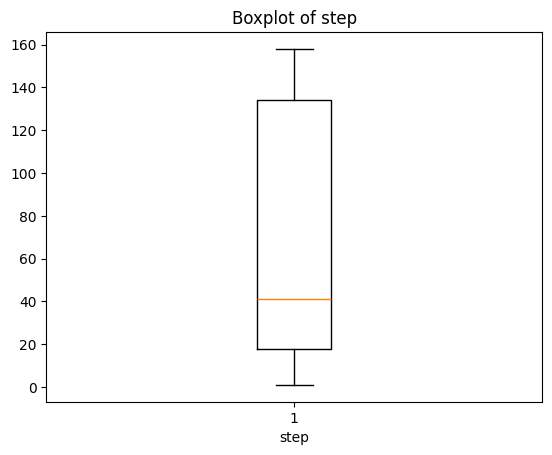

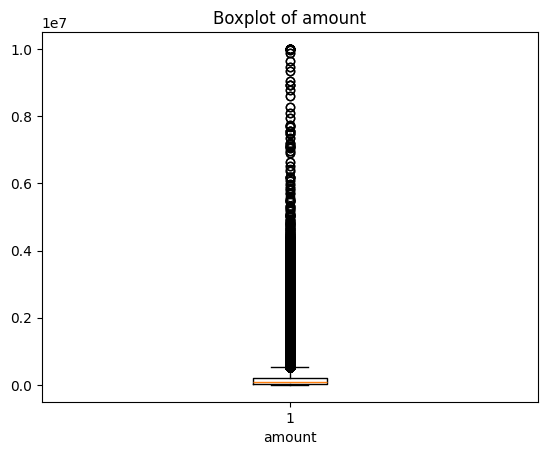

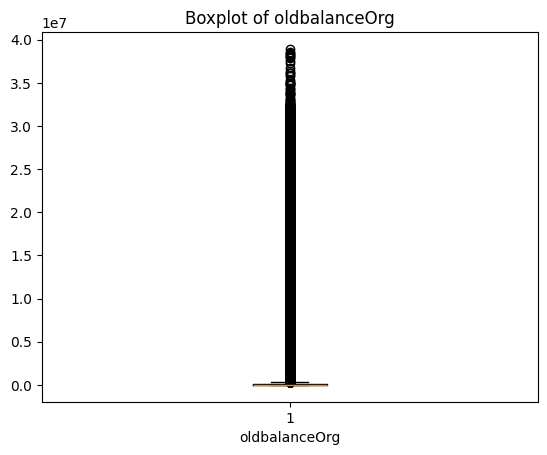

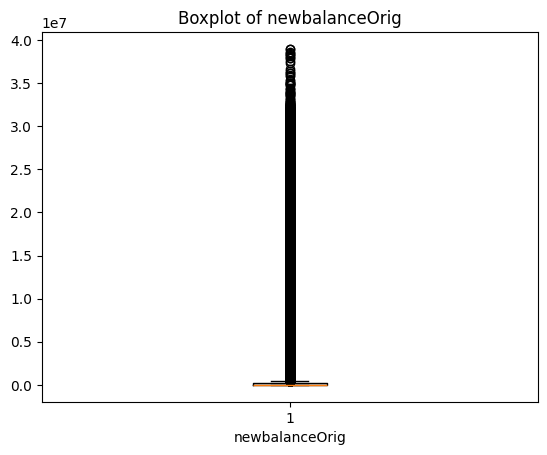

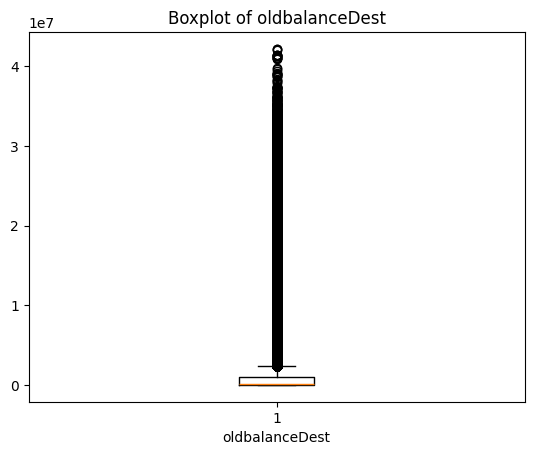

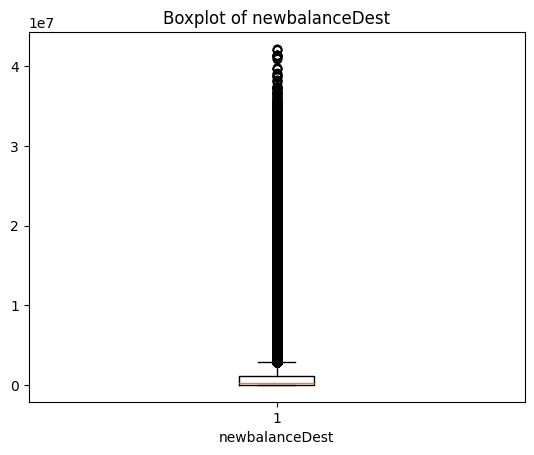

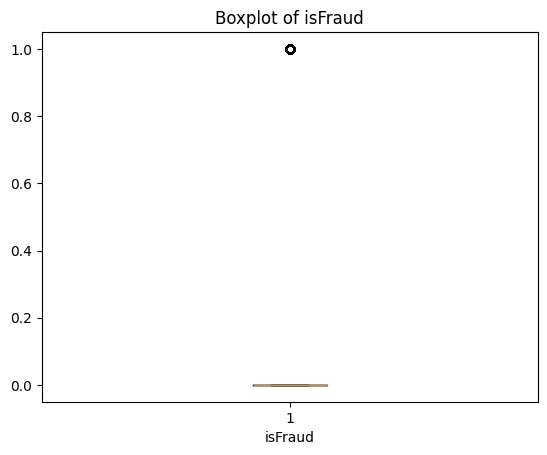

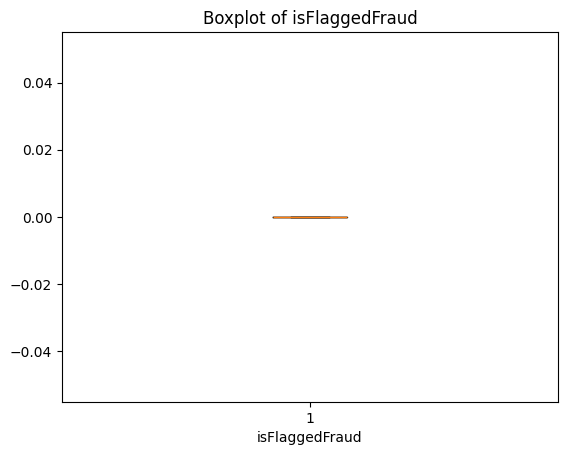

In [ ]:
for col in num_col:
    plt.figure()
    plt.boxplot(data[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.show()

In [ ]:
outlier_summary = {}

for col in num_col:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower) | (data[col] > upper)]

    outlier_summary[col] = len(outliers)

print(outlier_summary)

{'step': 0, 'amount': 84129, 'oldbalanceOrg': 290082, 'newbalanceOrig': 270544, 'oldbalanceDest': 197173, 'newbalanceDest': 180934, 'isFraud': 1802, 'isFlaggedFraud': 0}


In [ ]:
outliers_data = pd.DataFrame(list(outlier_summary.items()),
                            columns=['Column', 'Outlier Count'])

outliers_data = outliers_data.sort_values(by='Outlier Count', ascending=False)

print(outliers_data)

           Column  Outlier Count
2   oldbalanceOrg         290082
3  newbalanceOrig         270544
4  oldbalanceDest         197173
5  newbalanceDest         180934
1          amount          84129
6         isFraud           1802
0            step              0
7  isFlaggedFraud              0


In [ ]:
cols_to_cap = ['oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest','amount','step']
for col in cols_to_cap:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    data[col] = data[col].clip(lower,upper)

In [ ]:
outlier_summary = {}

for col in num_col:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower) | (data[col] > upper)]

    outlier_summary[col] = len(outliers)

print(outlier_summary)

{'step': 0, 'amount': 0, 'oldbalanceOrg': 0, 'newbalanceOrig': 0, 'oldbalanceDest': 0, 'newbalanceDest': 0, 'isFraud': 1802, 'isFlaggedFraud': 0}


In [ ]:
nominal_col = ['type']
data = pd.get_dummies(data,columns=nominal_col,drop_first=True)

In [ ]:
data.dtypes

,0
step,int64
amount,float64
oldbalanceOrg,float64
newbalanceOrig,float64
oldbalanceDest,float64
newbalanceDest,float64
isFraud,float64
isFlaggedFraud,float64
type_CASH_OUT,bool
type_DEBIT,bool


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data.drop('isFraud',axis=1)
y = data['isFraud']

Xtrain , Xtest , ytrain , ytest = train_test_split(X,y , test_size=0.2 , random_state=42)

num_col = X.select_dtypes(include=['int64','float64']).columns
scaler = StandardScaler()
Xtrain[num_col] = scaler.fit_transform(Xtrain[num_col])
Xtest[num_col] = scaler.transform(Xtest[num_col])


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(Xtrain , ytrain)

KNeighborsClassifier()

In [ ]:
y_pred = knn.predict(Xtest)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(ytest , y_pred)

0.9995167085257332

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(ytest , y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270904
           1       0.89      0.71      0.79      1620

    accuracy                           1.00   1272524
   macro avg       0.94      0.85      0.89   1272524
weighted avg       1.00      1.00      1.00   1272524



In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(ytest , y_pred)

array([[1270762,     142],
       [    473,    1147]])

In [ ]:
y_prob = knn.predict_proba(Xtest)[:, 1]

In [ ]:
from sklearn.metrics import roc_curve
fpr , tpr , thresholds = roc_curve(ytest , y_prob)

In [ ]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(ytest , y_prob)
print ('Auc:',auc)

Auc: 0.9177231004538966


<function matplotlib.pyplot.show(close=None, block=None)>

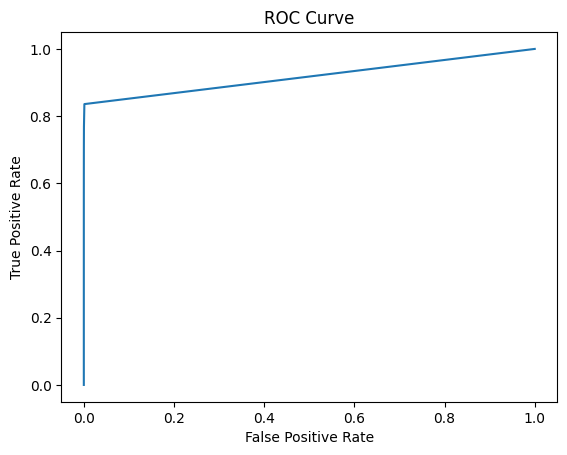

In [ ]:
plt.plot(fpr , tpr )
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show